In [1]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for all visualizations
sns.set_style("whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv('Churn_Modelling (3).csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Customer Churn Prediction using Support Vector Machine (SVM)

This notebook demonstrates a complete machine learning workflow for predicting customer churn using a Gradient Boosting Classifier.

## Steps in this Project:
1. **Data Loading & Exploration**: Load the dataset and understand its structure
2. **Data Cleaning**: Handle missing values and identify irrelevant features
3. **Data Preprocessing and Spliting**: Encode categorical variables and scale features
4. **Model Training**: Train a Support Vector Classifier (Linear kernel and Polynomial kernel)
5. **Model Evaluation**: Calculate F1-score performance metric
6. **Visualization**: Create histogram of predicted probabilities for both classes

## Step 1: Data Exploration
Let's first understand the structure of our dataset and check for any data quality issues.

In [3]:
# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names and Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (10000, 14)

Column Names and Data Types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Basic Statistics:
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000    

In [4]:
print("\nBasic Statistics:")
df.describe()


Basic Statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate Rows: 0


## Step 2: Data Cleaning
Now let's clean the data by removing irrelevant columns and checking the target variable distribution.

Target Variable Distribution (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64

Percentage Distribution:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


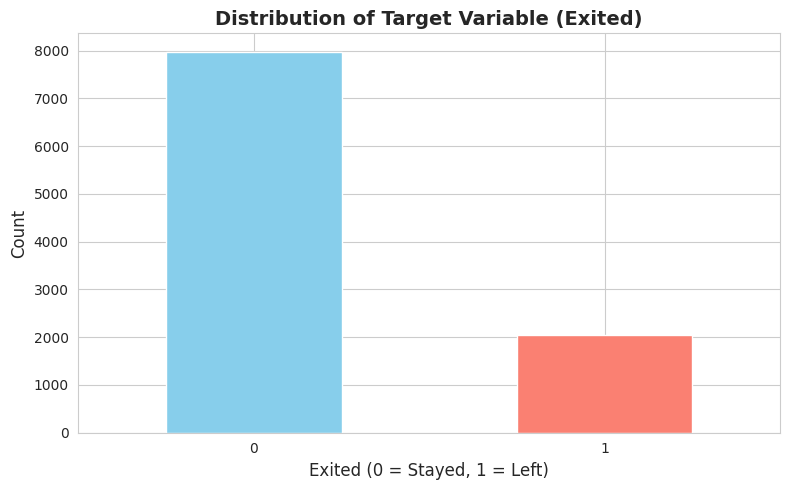

In [6]:
# Check target variable distribution
print("Target Variable Distribution (Exited):")
print(df['Exited'].value_counts())
print("\nPercentage Distribution:")
print(df['Exited'].value_counts(normalize=True) * 100)

# Visualize target distribution
plt.figure(figsize=(8, 5))
df['Exited'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Target Variable (Exited)', fontsize=14, fontweight='bold')
plt.xlabel('Exited (0 = Stayed, 1 = Left)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Remove irrelevant columns that don't contribute to prediction
# RowNumber, CustomerId, and Surname are not useful for prediction
print("Columns before cleaning:", df.columns.tolist())
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print("\nColumns after cleaning:", df_clean.columns.tolist())
print("\nCleaned dataset shape:", df_clean.shape)

Columns before cleaning: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Columns after cleaning: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Cleaned dataset shape: (10000, 11)


## Step 3: Data Preprocessing and Splitting
We need to encode categorical variables (Geography, Gender) and prepare the features for modeling.

In [8]:
# Separate features and target
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nCategorical columns:", X.select_dtypes(include='object').columns.tolist())

Features shape: (10000, 10)
Target shape: (10000,)

Categorical columns: ['Geography', 'Gender']


## Train-Test Split
Split the data into training (80%) and testing (20%) sets with stratification to maintain class balance.

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Encode categorical variables
categorical_columns = ['Geography', 'Gender']
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTarget distribution in testing set:")
print(y_test.value_counts(normalize=True) * 100)

Training set size: (8000, 10)
Testing set size: (2000, 10)

Target distribution in training set:
Exited
0    79.625
1    20.375
Name: proportion, dtype: float64

Target distribution in testing set:
Exited
0    79.65
1    20.35
Name: proportion, dtype: float64


In [10]:
# Scale the features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print("Training set mean:", X_train_scaled.mean(axis=0).round(2))
print("Training set std:", X_train_scaled.std(axis=0).round(2))

Features scaled successfully!
Training set mean: [-0. -0.  0.  0. -0.  0. -0.  0.  0. -0.]
Training set std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 4: Train Support Vector Machine Model
We train two Support Vector Machine (SVM) models using **linear** and **polynomial kernels** to classify whether a customer exited or stayed.

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Train Support Vector Machine (SVM) models
print("Training Support Vector Classifier...")

#Linear kernel SVM
sv_linear = SVC(
    kernel='linear',
    shrinking=True,
    class_weight='balanced',
    probability=True,
    random_state=42,
    verbose=0
)
sv_linear.fit(X_train_scaled, y_train)

#polynomial kernel SVM
sv_poly = SVC(
    kernel='poly',
    degree= 3,
    shrinking=True,
    class_weight='balanced',
    probability=True,
    random_state=42,
    verbose=0
)
sv_poly.fit(X_train_scaled, y_train)
print("Model training completed!")

Training Support Vector Classifier...
Model training completed!


## Step 5: Model Evaluation - F1 Score
Calculate the F1-score, which is the harmonic mean of precision and recall. This is particularly useful for imbalanced datasets.

MODEL PERFORMANCE METRICS

Linear Kernel
----------------------------------------
F1 Score: 0.5044

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.72      0.80      1593
      Exited       0.39      0.71      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000


Confusion Matrix:
[[1149  444]
 [ 120  287]]


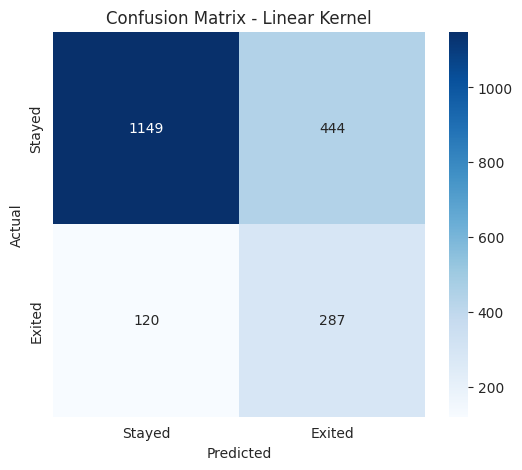


Polynomial Kernel
----------------------------------------
F1 Score: 0.5649

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.77      0.84      1593
      Exited       0.45      0.75      0.56       407

    accuracy                           0.76      2000
   macro avg       0.69      0.76      0.70      2000
weighted avg       0.83      0.76      0.78      2000


Confusion Matrix:
[[1220  373]
 [ 100  307]]


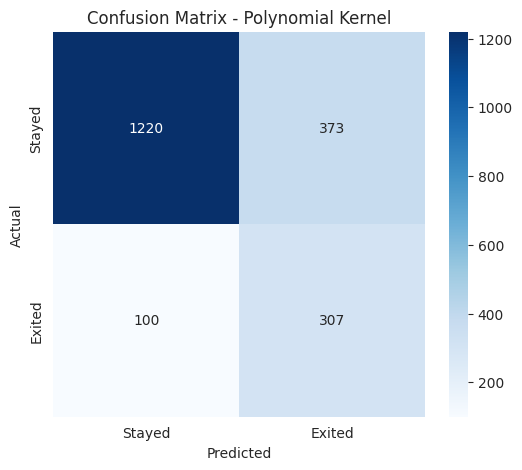


MODEL COMPARISON (F1 SCORE)
Linear Kernel: 0.5044
Polynomial Kernel: 0.5649


In [12]:
# Dictionary containing both trained models
models = {
    "Linear Kernel": sv_linear,
    "Polynomial Kernel": sv_poly
}

# Store probabilities for histogram later
probabilities = {}

# Store F1 scores for comparison
f1_scores = {}

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)

for name, model in models.items():

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Predicted probabilities
    y_proba = model.predict_proba(X_test_scaled)

    # Save probabilities for histogram plotting later
    probabilities[name] = y_proba

    # Calculate F1 Score
    f1 = f1_score(y_test, y_pred)

    # Store F1 score
    f1_scores[name] = f1

    print(f"\n{name}")
    print("-"*40)
    print(f"F1 Score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Exited']))

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stayed', 'Exited'],
                yticklabels=['Stayed', 'Exited'])

    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


# Model comparison summary
print("\n" + "="*60)
print("MODEL COMPARISON (F1 SCORE)")
print("="*60)

for model, score in f1_scores.items():
    print(f"{model}: {score:.4f}")

## Step 6: Predicted Probabilities Histogram
Visualize the distribution of predicted probabilities for both classes (Stayed vs Exited) to understand model confidence.

In [13]:
def plot_probability_histogram(y_test, y_proba, model_name):
    """
    Plot histogram of predicted probabilities for both classes.
    This helps visualize how well the model separates the two classes.
    """

    # Get probability of positive class (Exited = 1)
    proba_positive = y_proba[:, 1]

    # Separate probabilities by true class
    proba_stayed = proba_positive[y_test == 0]
    proba_exited = proba_positive[y_test == 1]

    # Plot histogram
    plt.figure(figsize=(10,5))

    plt.hist(proba_stayed, bins=30, alpha=0.6, label=f'Stayed (n={len(proba_stayed)})')
    plt.hist(proba_exited, bins=30, alpha=0.6, label=f'Exited (n={len(proba_exited)})')

    plt.xlabel("Predicted Probability of Exiting")
    plt.ylabel("Frequency")
    plt.title(f"Predicted Probability Distribution ({model_name})")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    # Print simple statistics
    print(f"\nStatistics for {model_name}")
    print("-"*40)
    print(f"Stayed  -> Mean: {proba_stayed.mean():.4f}, Std: {proba_stayed.std():.4f}")
    print(f"Exited  -> Mean: {proba_exited.mean():.4f}, Std: {proba_exited.std():.4f}")

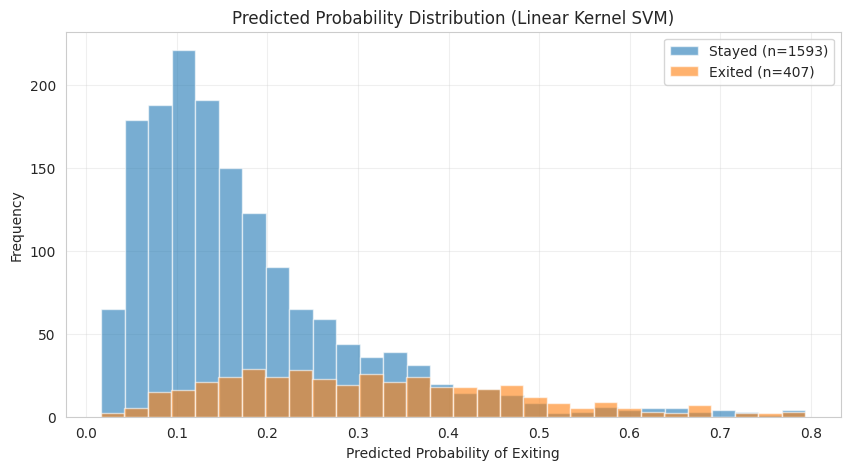


Statistics for Linear Kernel SVM
----------------------------------------
Stayed  -> Mean: 0.1747, Std: 0.1259
Exited  -> Mean: 0.3140, Std: 0.1581


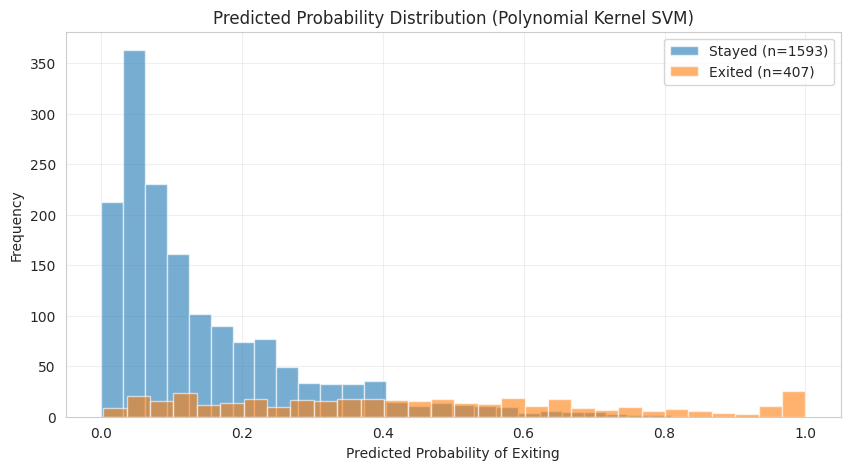


Statistics for Polynomial Kernel SVM
----------------------------------------
Stayed  -> Mean: 0.1460, Std: 0.1443
Exited  -> Mean: 0.4509, Std: 0.2793


In [14]:
plot_probability_histogram(y_test, probabilities["Linear Kernel"], "Linear Kernel SVM")
plot_probability_histogram(y_test, probabilities["Polynomial Kernel"], "Polynomial Kernel SVM")

## Summary and Key Findings

### Model Performance:
- **Algorithms Used**: Support Vector Machine (SVM)
  - Linear Kernel SVM
  - Polynomial Kernel SVM

- **F1-Scores**:
  - **Linear Kernel SVM**: 0.5044  
  - **Polynomial Kernel SVM**: 0.5649  

The **Polynomial Kernel performed better**, indicating that the dataset likely contains **non-linear relationships** between the features and the target variable.

---

## Steps Completed

### 1. **Data Loading & Exploration**
- Loaded the **Churn_Modelling.csv** dataset (10,000 rows, 14 columns)
- Examined data types, statistical summaries, and checked for missing values
- Verified that the dataset contains **no missing values or duplicate records**

---

### 2. **Data Cleaning**
- Removed irrelevant columns:
  - `RowNumber`
  - `CustomerId`
  - `Surname`

These columns do not provide useful information for predicting whether a customer will leave the bank.

- Examined the **target variable (Exited)** distribution
- Observed **class imbalance**, with approximately **20% of customers exiting**

---

### 3. **Data Preprocessing and Train-Test Split**
- Separated **features (X)** from the **target variable (y = Exited)**
- Encoded categorical variables using **Label Encoding**:
  - Geography: France (0), Germany (1), Spain (2)
  - Gender: Female (0), Male (1)

- Split the dataset into:
  - **80% training data**
  - **20% testing data**

- Used **stratified sampling** to maintain the same churn distribution in both sets

- Applied **StandardScaler** to normalize the feature values.

Feature scaling is particularly important for **SVM models**, since SVM relies on **distance calculations between data points**.

---

### 4. **Model Training**
Two Support Vector Machine models were trained:

#### **Linear Kernel SVM**
- Uses a **linear decision boundary**
- Works well when the data is approximately **linearly separable**

#### **Polynomial Kernel SVM**
- Uses a **non-linear decision boundary**
- Can capture **more complex relationships between variables**

Both models were trained using the **scaled training dataset**.

---

### 5. **Model Evaluation**
The models were evaluated using the **F1-score**, which is the harmonic mean of **precision** and **recall**.

Evaluation included:
- **F1-score comparison**
- **Classification report** (precision, recall, F1-score)
- **Confusion matrix visualization**

The **Polynomial Kernel SVM achieved a higher F1-score**, indicating better performance on this dataset.

---

### 6. **Probability Distribution Visualization**
Predicted probabilities were generated for the test dataset.

Histograms were created to visualize the probability distributions for both classes:

- **Green bars**: Customers who stayed (Class 0)
- **Red bars**: Customers who exited (Class 1)

Ideally:
- Customers who stayed should have **lower predicted probabilities**
- Customers who exited should have **higher predicted probabilities**

Better separation between these distributions indicates **stronger model confidence and predictive performance**.

---

## Key Learnings

- **Support Vector Machines (SVM)** are effective classification algorithms for datasets with clear decision boundaries.
- **Feature scaling is essential for SVM**, since the algorithm depends on distances between data points.
- **Different kernels allow SVM to capture different patterns in the data**:
  - Linear kernels capture simpler relationships
  - Polynomial kernels capture more complex, non-linear patterns
- **F1-score is a useful evaluation metric for imbalanced datasets**, as it balances precision and recall.
- **Probability histograms help visualize model confidence** and show how well the model separates the two classes.

## Conclusion

Two Support Vector Machine models were trained using linear and polynomial kernels.

The **Polynomial Kernel SVM achieved a higher F1-score**, indicating that the dataset likely contains non-linear relationships between the features and the target variable.

Therefore, the **Polynomial Kernel SVM performs better for this churn prediction task**.